# Proyecto BD-141 Big Data — Fase 6: Escalabilidad, Nube y Optimización

**Human Behavior AI: Detección de Manipulación Digital y Comportamiento Artificial**

| | |
|---|---|
| **Integrantes** | Mariana Méndez Pérez, Luis Diego Montero Vargas, Josué Redondo Gómez, Claret Rodríguez Jiménez, Nadin Rojas López |
| **Profesora** | Ericka Valverde Navarro |
| **Curso** | BD-141 Big Data |
| **Institución** | Colegio Universitario de Cartago |
| **Cuatrimestre** | II — 2026 |

---

## Objetivo de esta fase

Analizar cómo el sistema Human Behavior AI funcionaría en ambientes reales de producción,
evaluando estrategias de escalabilidad, uso de servicios en la nube, seguridad,
gobierno de datos, riesgos, costos aproximados y posibles mejoras futuras.

---
## 1. Explicación de Escalabilidad

El sistema fue diseñado desde la Fase 2 con una arquitectura por capas que
facilita el crecimiento progresivo sin necesidad de rediseñar la solución completa.

### 1.1 Situación actual

En las fases anteriores el sistema procesó:
- **53,500 registros** integrados desde 3 fuentes
- **5 lotes** de datos en tiempo real con tiempos < 0.05 segundos por lote
- **1 modelo** Random Forest con 16 features

Este volumen es manejable con las herramientas actuales (Python + Pandas + Scikit-Learn).
Sin embargo, en un entorno real las plataformas digitales generan millones de eventos
por hora, lo que requiere una estrategia de escalabilidad definida.

### 1.2 Estrategias de escalabilidad propuestas

**Escalabilidad horizontal — procesamiento distribuido:**
Cuando el volumen de datos supere la capacidad de procesamiento local, se propone
migrar la capa de procesamiento a **Apache Spark**, que permite distribuir el trabajo
entre múltiples nodos. Esta transición fue prevista desde la Fase 2 como plan de
crecimiento del sistema.

**Particionado de datos:**
La tabla `raw_events` de PostgreSQL sería particionada horizontalmente por fecha
(día u hora), evitando escaneos masivos de índices y mejorando los tiempos
de consulta conforme crece el volumen.

**Réplicas de lectura:**
Las consultas del dashboard de Streamlit operarían sobre réplicas de lectura
independientes del servidor principal, evitando que las visualizaciones compitan
con la ingesta y el procesamiento de datos nuevos.

**Procesamiento asíncrono:**
Los lotes de datos entrantes serían gestionados mediante colas de mensajes
(como Apache Kafka), permitiendo que el sistema reciba datos continuamente
sin bloquear el procesamiento de lotes anteriores.

### 1.3 Capacidad estimada por etapa

| Etapa | Volumen de datos | Tecnología principal |
|---|---|---|
| Actual (académico) | ~53,500 registros | Python + Pandas |
| Escala media | Millones de registros | PostgreSQL particionado + Spark |
| Escala alta | Miles de millones de eventos | Spark + Kafka + Cloud Storage |

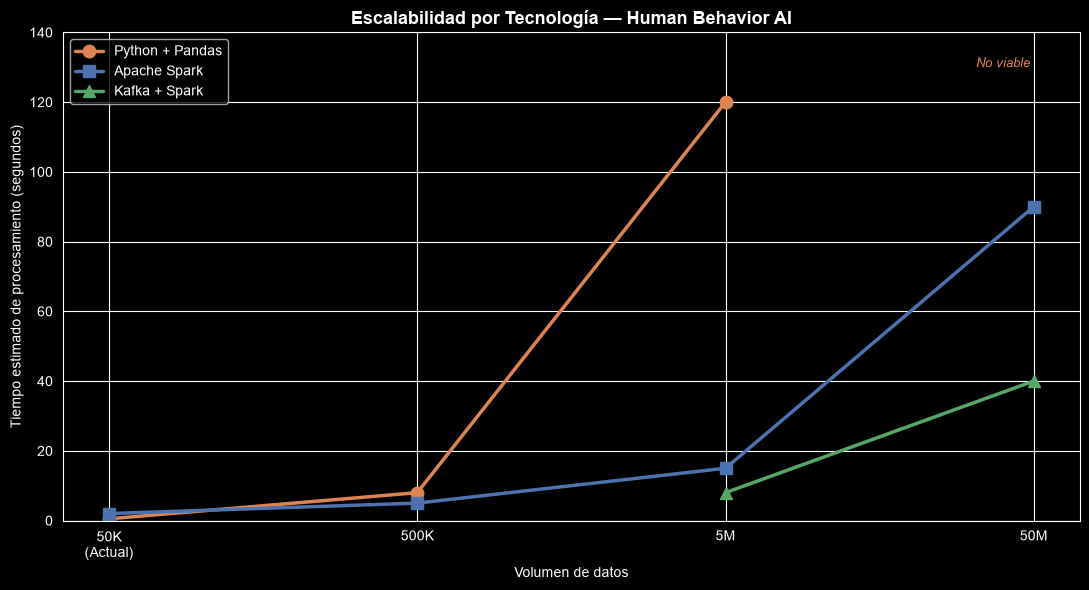

 Gráfico guardado como 'escalabilidad.png'


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Simulación de tiempos de procesamiento según volumen y tecnología
volumenes = [50_000, 500_000, 5_000_000, 50_000_000]
etiquetas = ['50K\n(Actual)', '500K', '5M', '50M']

# Tiempos estimados en segundos para cada tecnología
tiempos_pandas = [0.5, 8, 120, None]       # Pandas colapsa en 50M
tiempos_spark  = [2, 5, 15, 90]            # Spark escala bien
tiempos_kafka  = [None, None, 8, 40]       # Kafka aplica a alto volumen

fig, ax = plt.subplots(figsize=(11, 6))

x = range(len(volumenes))

# Pandas
pandas_vals = [t if t is not None else 0 for t in tiempos_pandas]
ax.plot(x[:3], pandas_vals[:3], marker='o', color='#DD8452',
        linewidth=2.5, markersize=9, label='Python + Pandas')
ax.annotate(' No viable', xy=(2.8, 130), color='#DD8452',
            fontsize=9, fontstyle='italic')

# Spark
ax.plot(x, tiempos_spark, marker='s', color='#4C72B0',
        linewidth=2.5, markersize=9, label='Apache Spark')

# Kafka + Spark
kafka_vals = [None, None, 8, 40]
ax.plot(x[2:], [8, 40], marker='^', color='#55A868',
        linewidth=2.5, markersize=9, label='Kafka + Spark')

ax.set_xticks(list(x))
ax.set_xticklabels(etiquetas)
ax.set_ylabel('Tiempo estimado de procesamiento (segundos)')
ax.set_xlabel('Volumen de datos')
ax.set_title('Escalabilidad por Tecnología — Human Behavior AI',
             fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0, 140)

plt.tight_layout()
plt.savefig('escalabilidad.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Gráfico guardado como 'escalabilidad.png'")

---
## 2. Uso Potencial de Nube

Para escalar el sistema a un entorno de producción real, se propone una
arquitectura cloud basada en servicios administrados que eliminen la necesidad
de gestionar infraestructura física.

### 2.1 Proveedor recomendado: Google Cloud Platform (GCP)

Se selecciona GCP como proveedor principal por las siguientes razones:
- Compatible con las herramientas ya utilizadas en el proyecto (Python, Colab, BigQuery)
- Ofrece servicios administrados para cada capa del pipeline actual
- Tiene una capa gratuita que permitiría continuar el desarrollo académico

### 2.2 Mapeo de tecnologías actuales a servicios cloud

| Capa | Tecnología actual | Servicio GCP equivalente |
|---|---|---|
| Ingesta de datos | CSV manual / scripts Python | Cloud Pub/Sub |
| Procesamiento | Python + Pandas | Dataflow (Apache Beam) |
| Almacenamiento | PostgreSQL local | BigQuery + Cloud SQL |
| Modelo de IA | Scikit-Learn local | Vertex AI |
| Visualización | Streamlit local | Looker Studio / Cloud Run |
| Orquestación | Ejecución manual | Cloud Composer (Airflow) |

### 2.3 Arquitectura cloud propuesta

El flujo en la nube seguiría el mismo pipeline definido en Fase 2 y ejecutado
en Fase 5, pero con cada componente reemplazado por su equivalente administrado:

**Ingesta → Pub/Sub:** los eventos de las plataformas digitales llegarían
como mensajes en tiempo real a un tópico de Pub/Sub, eliminando la necesidad
de generar lotes manualmente.

**Procesamiento → Dataflow:** los mensajes serían procesados por un pipeline
de Apache Beam en Dataflow, aplicando las mismas transformaciones de la Fase 3
de forma distribuida y escalable.

**Almacenamiento → BigQuery:** los datos procesados y las predicciones se
almacenarían en BigQuery, que permite consultas SQL sobre miles de millones
de registros en segundos sin necesidad de índices ni particionado manual.

**Modelo → Vertex AI:** el modelo Random Forest sería desplegado como un
endpoint en Vertex AI, permitiendo clasificar cuentas nuevas mediante
llamadas a una API REST sin necesidad de reentrenar localmente.

**Visualización → Looker Studio:** el dashboard de Streamlit sería reemplazado
por Looker Studio conectado directamente a BigQuery, permitiendo visualizaciones
en tiempo real accesibles desde cualquier navegador.

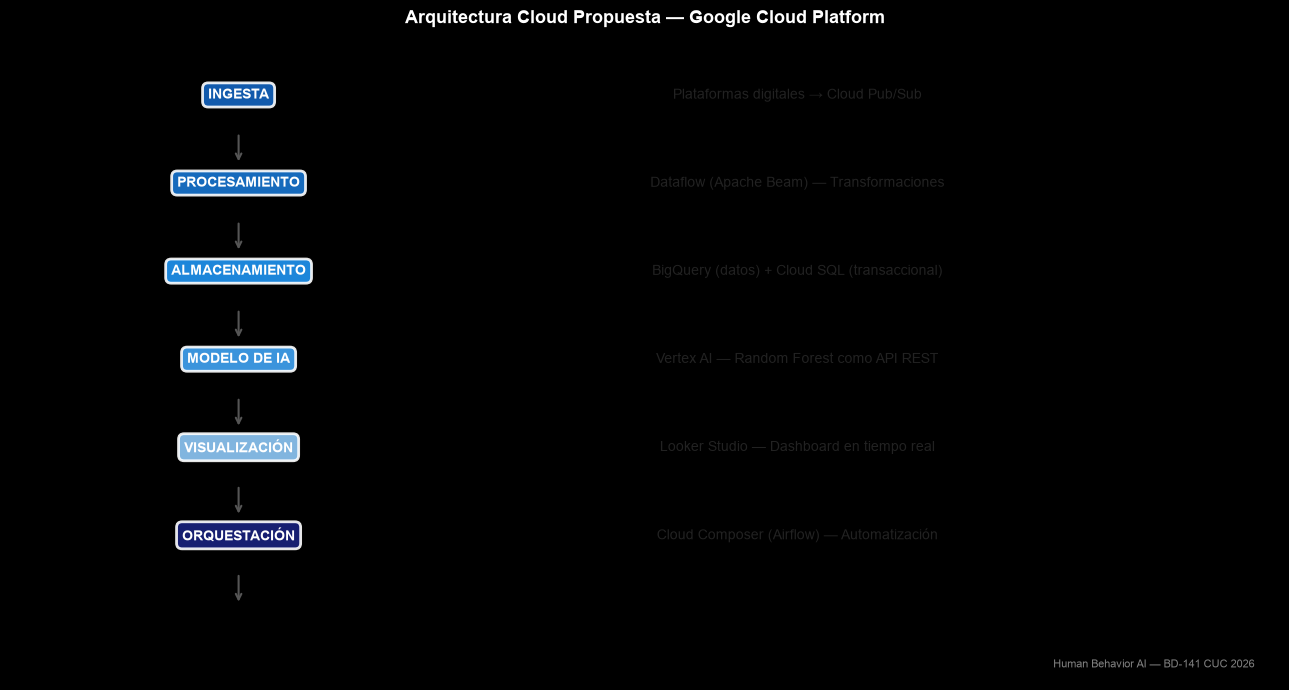

 Diagrama guardado como 'arquitectura_cloud.png'


In [27]:
# Diagrama visual de arquitectura cloud
fig, ax = plt.subplots(figsize=(13, 7))
ax.axis('off')

capas = [
    ("INGESTA",        "Plataformas digitales → Cloud Pub/Sub",           "#1565C0"),
    ("PROCESAMIENTO",  "Dataflow (Apache Beam) — Transformaciones",        "#1976D2"),
    ("ALMACENAMIENTO", "BigQuery (datos) + Cloud SQL (transaccional)",     "#2196F3"),
    ("MODELO DE IA",   "Vertex AI — Random Forest como API REST",          "#42A5F5"),
    ("VISUALIZACIÓN",  "Looker Studio — Dashboard en tiempo real",         "#90CAF9"),
    ("ORQUESTACIÓN",   "Cloud Composer (Airflow) — Automatización",        "#1A237E"),
]

y_pos = 0.93
for nombre, descripcion, color in capas:
    fancy = dict(boxstyle="round,pad=0.4", facecolor=color,
                 alpha=0.9, edgecolor='white', linewidth=2)
    ax.text(0.18, y_pos, nombre,
            transform=ax.transAxes,
            fontsize=10, fontweight='bold', color='white',
            ha='center', va='center', bbox=fancy)
    ax.text(0.62, y_pos, descripcion,
            transform=ax.transAxes,
            fontsize=10, color='#222222',
            ha='center', va='center')
    if y_pos > 0.15:
        ax.annotate('', xy=(0.18, y_pos - 0.11),
                    xytext=(0.18, y_pos - 0.06),
                    xycoords='axes fraction',
                    textcoords='axes fraction',
                    arrowprops=dict(arrowstyle='->',
                                   color='#555555', lw=1.5))
    y_pos -= 0.14

ax.set_title('Arquitectura Cloud Propuesta — Google Cloud Platform',
             fontsize=13, fontweight='bold', pad=20)
ax.text(0.98, 0.02, 'Human Behavior AI — BD-141 CUC 2026',
        transform=ax.transAxes, fontsize=8,
        color='gray', ha='right')

plt.tight_layout()
plt.savefig('arquitectura_cloud.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Diagrama guardado como 'arquitectura_cloud.png'")

---
## 3. Seguridad de Datos

El manejo de datos de comportamiento de usuarios en plataformas digitales
implica responsabilidades importantes en materia de seguridad y privacidad.

### 3.1 Principios de seguridad aplicados

**Cifrado de datos:**
- Datos en tránsito: cifrado TLS 1.3 en todas las comunicaciones entre componentes
- Datos en reposo: cifrado AES-256 en BigQuery y Cloud SQL
- Modelos de IA: almacenados en buckets de Cloud Storage con acceso restringido

**Control de acceso:**
- Autenticación mediante IAM (Identity and Access Management) de GCP
- Principio de mínimo privilegio: cada componente accede únicamente
  a los recursos que necesita
- Separación de roles: ingesta, procesamiento, análisis y visualización
  operan con cuentas de servicio independientes

**Anonimización de datos:**
- Los identificadores de usuario (user_id) son hasheados antes de almacenarse
- Los datos de comportamiento se desvinculan de información personal identificable
- Solo se conservan las variables necesarias para la detección de bots

### 3.2 Cumplimiento normativo

El sistema debe cumplir con las siguientes regulaciones según el contexto
de operación:

| Regulación | Alcance | Aplicación en el sistema |
|---|---|---|
| GDPR | Usuarios europeos | Anonimización y derecho al olvido |
| CCPA | Usuarios de California | Transparencia en uso de datos |
| Ley 8968 CR | Usuarios costarricenses | Protección de datos personales |

### 3.3 Monitoreo de seguridad

- **Logs de auditoría:** registro de todos los accesos a datos sensibles
- **Alertas de anomalías:** detección de patrones de acceso inusuales
- **Revisión periódica:** evaluación trimestral de permisos y accesos activos

---
## 4. Gobierno de Datos

El gobierno de datos define las políticas, procesos y responsabilidades
que garantizan la calidad, trazabilidad e integridad de la información
a lo largo de todo el pipeline del sistema.

### 4.1 Principios de gobierno aplicados al proyecto

**Trazabilidad completa:**
Desde la Fase 3 el sistema conserva los datos originales en la tabla
`raw_events` sin modificaciones, permitiendo rastrear cualquier registro
hasta su fuente original. Las transformaciones se almacenan en capas
separadas (processed_sessions, model_predictions), manteniendo la
trazabilidad end-to-end definida en la Fase 2.

**Calidad de datos:**
Cada lote de datos entrante pasa por una etapa de validación automática
que verifica estructura, tipos de datos y valores mínimos requeridos
antes de ser procesado. Los registros que no cumplen los criterios
son almacenados en una tabla de cuarentena para revisión posterior.

**Catalogación:**
Todas las variables del sistema están documentadas con nombre, tipo,
descripción y origen, facilitando el mantenimiento y la incorporación
de nuevos miembros al equipo.

### 4.2 Roles y responsabilidades

| Rol | Responsabilidad |
|---|---|
| Data Engineer | Mantenimiento del pipeline y calidad de datos |
| Data Scientist | Entrenamiento y evaluación de modelos de IA |
| Data Analyst | Interpretación de resultados y dashboards |
| Data Steward | Cumplimiento normativo y gobierno de datos |
| Administrador | Seguridad, accesos y infraestructura |

### 4.3 Ciclo de vida del dato

Los datos en el sistema siguen el siguiente ciclo de vida:

1. **Ingesta** → datos crudos recibidos desde fuentes externas
2. **Validación** → verificación de estructura e integridad
3. **Procesamiento** → limpieza y creación de variables
4. **Análisis** → clasificación con modelos de IA
5. **Retención** → almacenamiento por 12 meses en capa activa
6. **Archivo** → datos históricos en almacenamiento frío tras 12 meses
7. **Eliminación** → borrado seguro conforme a normativas vigentes

---
## 5. Riesgos del Sistema

Se identifican los principales riesgos técnicos, operativos y de negocio
que podrían afectar el funcionamiento del sistema en producción.

In [28]:
# Tabla de riesgos con nivel de impacto y probabilidad
riesgos = {
    'Riesgo': [
        'Bots sofisticados que evaden el modelo',
        'Degradación del modelo con el tiempo',
        'Fallo en la ingesta de datos',
        'Brecha de seguridad o acceso no autorizado',
        'Dataset desbalanceado en producción',
        'Latencia alta en procesamiento en tiempo real',
        'Falsos positivos que afecten usuarios legítimos',
        'Cambios en APIs de plataformas externas'
    ],
    'Probabilidad': [
        'Alta', 'Alta', 'Media', 'Baja',
        'Media', 'Media', 'Alta', 'Alta'
    ],
    'Impacto': [
        'Alto', 'Alto', 'Alto', 'Alto',
        'Medio', 'Medio', 'Medio', 'Alto'
    ],
    'Estrategia de mitigación': [
        'Reentrenamiento periódico con datos recientes',
        'Monitoreo continuo de métricas y alertas de degradación',
        'Sistema de reintentos automáticos y colas de respaldo',
        'IAM + cifrado + logs de auditoría + revisiones periódicas',
        'Técnicas SMOTE + class_weight en cada reentrenamiento',
        'Particionado + réplicas de lectura + Apache Kafka',
        'Umbral de alerta ajustable + revisión manual de casos límite',
        'Abstracción de fuentes + conectores intercambiables'
    ]
}

df_riesgos = pd.DataFrame(riesgos)

# Colores por nivel
color_prob = {'Alta': '#C44E52', 'Media': '#DD8452', 'Baja': '#55A868'}
color_imp  = {'Alto': '#C44E52', 'Medio': '#DD8452', 'Bajo': '#55A868'}

print(" MATRIZ DE RIESGOS — Human Behavior AI")
print("=" * 60)
display(df_riesgos.style
    .map(lambda v: f'background-color: {color_prob.get(v, "white")}; color: white',
              subset=['Probabilidad'])
    .map(lambda v: f'background-color: {color_imp.get(v, "white")}; color: white',
              subset=['Impacto'])
    .set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'})
    .set_table_styles([{
        'selector': 'th',
        'props': [('font-weight', 'bold'),
                  ('background-color', '#f0f0f0')]
    }])
)

 MATRIZ DE RIESGOS — Human Behavior AI


,Riesgo,Probabilidad,Impacto,Estrategia de mitigación
0,Bots sofisticados que evaden el modelo,Alta,Alto,Reentrenamiento periódico con datos recientes
1,Degradación del modelo con el tiempo,Alta,Alto,Monitoreo continuo de métricas y alertas de degradación
2,Fallo en la ingesta de datos,Media,Alto,Sistema de reintentos automáticos y colas de respaldo
3,Brecha de seguridad o acceso no autorizado,Baja,Alto,IAM + cifrado + logs de auditoría + revisiones periódicas
4,Dataset desbalanceado en producción,Media,Medio,Técnicas SMOTE + class_weight en cada reentrenamiento
5,Latencia alta en procesamiento en tiempo real,Media,Medio,Particionado + réplicas de lectura + Apache Kafka
6,Falsos positivos que afecten usuarios legítimos,Alta,Medio,Umbral de alerta ajustable + revisión manual de casos límite
7,Cambios en APIs de plataformas externas,Alta,Alto,Abstracción de fuentes + conectores intercambiables


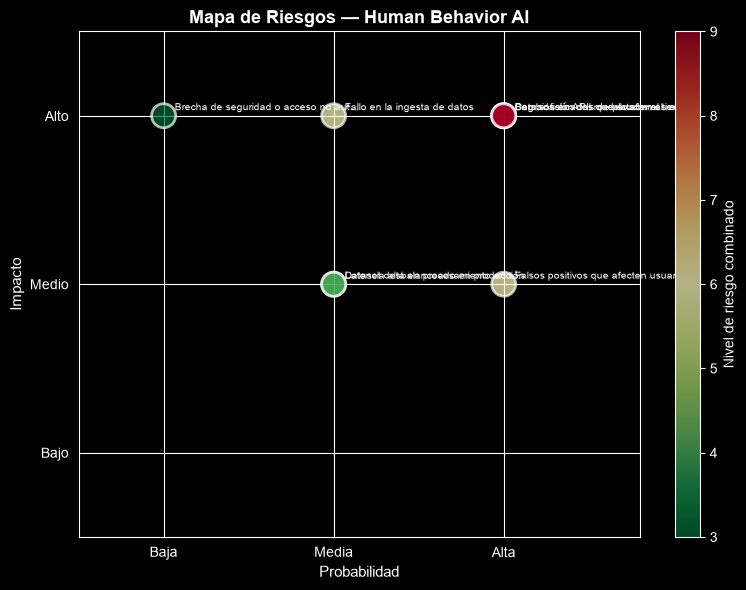

 Gráfico guardado como 'mapa_riesgos.png'


In [29]:
# Mapa de calor probabilidad vs impacto
fig, ax = plt.subplots(figsize=(8, 6))

niveles = {'Baja': 1, 'Media': 2, 'Alta': 3}
impactos = {'Bajo': 1, 'Medio': 2, 'Alto': 3}

prob_vals = [niveles[p] for p in df_riesgos['Probabilidad']]
imp_vals  = [impactos[i] for i in df_riesgos['Impacto']]

scatter = ax.scatter(prob_vals, imp_vals,
                     s=300, alpha=0.7,
                     c=[p*i for p, i in zip(prob_vals, imp_vals)],
                     cmap='RdYlGn_r', edgecolors='white',
                     linewidth=2)

for i, riesgo in enumerate(df_riesgos['Riesgo']):
    nombre_corto = riesgo[:35] + '...' if len(riesgo) > 35 else riesgo
    ax.annotate(nombre_corto,
                (prob_vals[i], imp_vals[i]),
                textcoords='offset points',
                xytext=(8, 4), fontsize=7.5)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Baja', 'Media', 'Alta'])
ax.set_yticks([1, 2, 3])
ax.set_yticklabels(['Bajo', 'Medio', 'Alto'])
ax.set_xlabel('Probabilidad', fontsize=11)
ax.set_ylabel('Impacto', fontsize=11)
ax.set_title('Mapa de Riesgos — Human Behavior AI',
             fontsize=13, fontweight='bold')
ax.set_xlim(0.5, 3.8)
ax.set_ylim(0.5, 3.5)

plt.colorbar(scatter, ax=ax, label='Nivel de riesgo combinado')
plt.tight_layout()
plt.savefig('mapa_riesgos.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Gráfico guardado como 'mapa_riesgos.png'")

---
## 6. Costos Aproximados

In [30]:
# Estimación de costos mensuales en GCP
componentes = {
    'Componente': [
        'Cloud Pub/Sub (ingesta)',
        'Dataflow (procesamiento)',
        'BigQuery (almacenamiento)',
        'BigQuery (consultas)',
        'Vertex AI (modelo)',
        'Cloud Run (dashboard)',
        'Cloud Storage (archivos)',
        'Cloud Composer (orquestación)'
    ],
    'Uso estimado': [
        '10GB mensajes/mes',
        '50 horas proceso/mes',
        '500GB datos/mes',
        '10TB consultas/mes',
        '100K predicciones/mes',
        '200 horas activo/mes',
        '1TB archivos/mes',
        '1 ambiente básico'
    ],
    'Costo USD/mes': [
        8.00, 35.00, 10.00, 50.00,
        18.00, 15.00, 23.00, 400.00
    ]
}

df_costos = pd.DataFrame(componentes)
df_costos['Costo USD/mes'] = df_costos['Costo USD/mes'].apply(
    lambda x: f"${x:,.2f}"
)

total = 559.00

print(" ESTIMACIÓN DE COSTOS MENSUALES — GCP")
print("=" * 55)
display(df_costos.style
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([{
        'selector': 'th',
        'props': [('font-weight', 'bold'),
                  ('background-color', '#f0f0f0')]
    }])
)
print(f"\n   Costo total estimado:  ${total:,.2f} USD/mes")
print(f"   Nota: Cloud Composer representa el 71% del costo total.")
print(f"          Una alternativa más económica sería usar")
print(f"          Cloud Scheduler (~$5/mes) para proyectos pequeños.")
print(f"\n   Con Cloud Scheduler en lugar de Composer:")
print(f"          Costo estimado reducido: ~$164.00 USD/mes")

 ESTIMACIÓN DE COSTOS MENSUALES — GCP


,Componente,Uso estimado,Costo USD/mes
0,Cloud Pub/Sub (ingesta),10GB mensajes/mes,$8.00
1,Dataflow (procesamiento),50 horas proceso/mes,$35.00
2,BigQuery (almacenamiento),500GB datos/mes,$10.00
3,BigQuery (consultas),10TB consultas/mes,$50.00
4,Vertex AI (modelo),100K predicciones/mes,$18.00
5,Cloud Run (dashboard),200 horas activo/mes,$15.00
6,Cloud Storage (archivos),1TB archivos/mes,$23.00
7,Cloud Composer (orquestación),1 ambiente básico,$400.00



   Costo total estimado:  $559.00 USD/mes
   Nota: Cloud Composer representa el 71% del costo total.
          Una alternativa más económica sería usar
          Cloud Scheduler (~$5/mes) para proyectos pequeños.

   Con Cloud Scheduler en lugar de Composer:
          Costo estimado reducido: ~$164.00 USD/mes


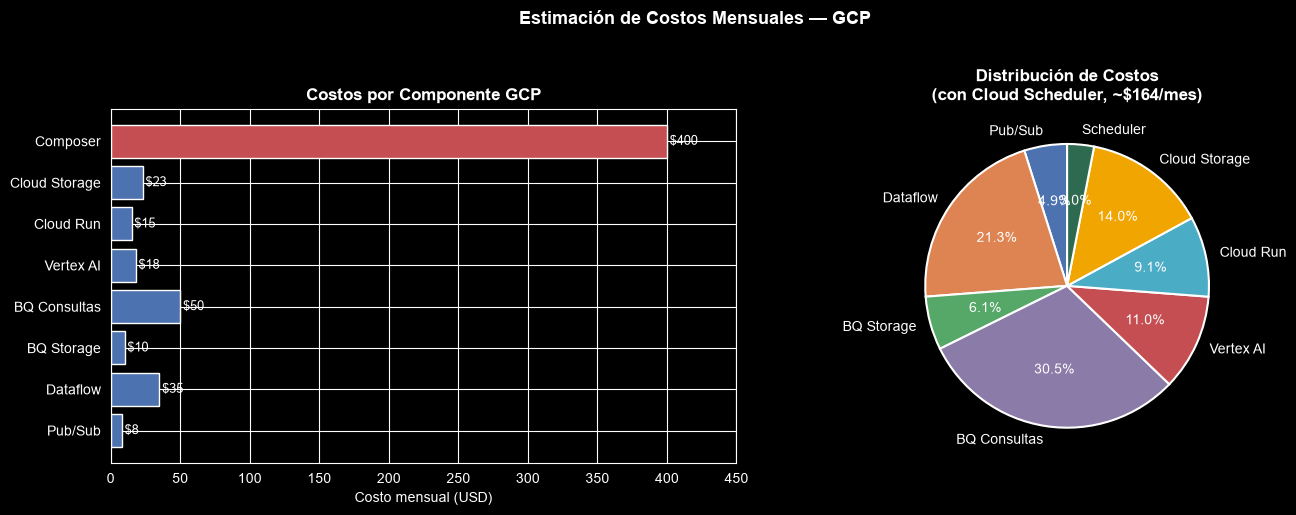

 Gráfico guardado como 'costos_gcp.png'


In [31]:
costos_vals = [8, 35, 10, 50, 18, 15, 23, 400]
componentes_labels = [
    'Pub/Sub', 'Dataflow', 'BQ Storage',
    'BQ Consultas', 'Vertex AI',
    'Cloud Run', 'Cloud Storage', 'Composer'
]

colores = ['#4C72B0' if c < 100 else '#C44E52' for c in costos_vals]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: barras
bars = axes[0].barh(componentes_labels, costos_vals,
                    color=colores, edgecolor='white')
axes[0].set_xlabel('Costo mensual (USD)')
axes[0].set_title('Costos por Componente GCP',
                  fontsize=12, fontweight='bold')
for bar in bars:
    axes[0].text(bar.get_width() + 2,
                 bar.get_y() + bar.get_height()/2,
                 f'${bar.get_width():.0f}',
                 va='center', fontsize=9)
axes[0].set_xlim(0, 450)

# Gráfico 2: pie sin Composer vs con Composer
costos_sin_composer = [8, 35, 10, 50, 18, 15, 23, 5]
labels_pie = [
    'Pub/Sub', 'Dataflow', 'BQ Storage',
    'BQ Consultas', 'Vertex AI',
    'Cloud Run', 'Cloud Storage', 'Scheduler'
]
colores_pie = ['#4C72B0', '#DD8452', '#55A868', '#8B7BA8',
               '#C44E52', '#4BACC6', '#F0A500', '#2D6A4F']

axes[1].pie(costos_sin_composer,
            labels=labels_pie,
            autopct='%1.1f%%',
            colors=colores_pie,
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Distribución de Costos\n(con Cloud Scheduler, ~$164/mes)',
                  fontsize=12, fontweight='bold')

plt.suptitle('Estimación de Costos Mensuales — GCP',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('costos_gcp.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Gráfico guardado como 'costos_gcp.png'")

---
## 7. Posibles Mejoras Futuras

A partir de los hallazgos obtenidos en las fases anteriores, se identifican
las siguientes mejoras que fortalecerían el sistema en versiones futuras.

### 7.1 Mejoras en el modelo de IA

**Variables de sesión y secuencia:**
El principal hallazgo de la Fase 4 fue que las variables disponibles en el
dataset actual no fueron suficientes para separar bots de humanos de forma
efectiva. La incorporación de variables de sesión como tiempo entre eventos,
secuencias de clics y patrones de navegación, planificadas desde la Fase 2,
mejoraría significativamente el poder predictivo del modelo.

**Modelos más avanzados:**
- **XGBoost o LightGBM:** mayor precisión que Random Forest con datasets grandes
- **Redes neuronales LSTM:** captura de patrones secuenciales en el comportamiento
- **Modelos de grafos:** detección de botnets mediante análisis de redes de usuarios

**Reentrenamiento continuo:**
Implementar un pipeline de reentrenamiento automático que actualice el modelo
mensualmente con datos nuevos, evitando la degradación del rendimiento conforme
los bots evolucionan y cambian sus patrones de comportamiento.

### 7.2 Mejoras en el pipeline

**Procesamiento en streaming real:**
Migrar de procesamiento por lotes a streaming con Apache Kafka + Spark Structured
Streaming, permitiendo clasificar cuentas en menos de un segundo desde que
generan su primera interacción.

**Enriquecimiento de datos:**
Incorporar fuentes externas como listas negras de IPs conocidas, bases de datos
de bots reportados y feeds de inteligencia de amenazas digitales para enriquecer
cada registro antes de clasificarlo.

**API de detección:**
Exponer el modelo como una API REST mediante Vertex AI o FastAPI, permitiendo
que otras plataformas consulten el sistema de detección en tiempo real sin
necesidad de integrar el pipeline completo.

### 7.3 Mejoras en visualización

**Dashboard en tiempo real:**
Reemplazar el dashboard estático de Streamlit por uno conectado directamente
a BigQuery mediante Looker Studio, mostrando métricas actualizadas cada minuto.

**Sistema de alertas automáticas:**
Integrar notificaciones por correo o Slack cuando el porcentaje de bots
detectados supere un umbral definido, permitiendo respuesta inmediata del
equipo de seguridad.

---
## 8. Optimización Propuesta

### 8.1 Optimización del modelo actual

Dado el rendimiento cercano al 50% obtenido en la Fase 4, se proponen las
siguientes optimizaciones aplicables sin necesidad de cambiar el dataset:

In [32]:
# Comparativa de estrategias de optimización
optimizaciones = {
    'Estrategia': [
        'Modelo actual (Random Forest)',
        'Ajuste de hiperparámetros (GridSearch)',
        'Incorporar variables de sesión',
        'XGBoost con variables de sesión',
        'Ensemble de modelos',
        'Deep Learning (LSTM)'
    ],
    'Complejidad': [
        'Baja', 'Baja', 'Media', 'Media', 'Alta', 'Muy Alta'
    ],
    'Mejora estimada en F1': [
        '50%', '52-55%', '65-75%', '75-85%', '80-88%', '85-92%'
    ],
    'Tiempo de implementación': [
        'Completado', '1 semana', '2-3 semanas',
        '3-4 semanas', '4-6 semanas', '2-3 meses'
    ],
    'Prioridad': [
        '—', 'Alta', 'Alta', 'Media', 'Media', 'Baja'
    ]
}

df_opt = pd.DataFrame(optimizaciones)

colores_prioridad = {
    'Alta': '#55A868', 'Media': '#DD8452',
    'Baja': '#C44E52', '—': '#AAAAAA'
}

print("  PLAN DE OPTIMIZACIÓN — Human Behavior AI")
print("=" * 60)
display(df_opt.style
    .map(
        lambda v: f'background-color: {colores_prioridad.get(v, "white")}; color: white',
        subset=['Prioridad']
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([{
        'selector': 'th',
        'props': [('font-weight', 'bold'),
                  ('background-color', '#f0f0f0')]
    }])
)

  PLAN DE OPTIMIZACIÓN — Human Behavior AI


,Estrategia,Complejidad,Mejora estimada en F1,Tiempo de implementación,Prioridad
0,Modelo actual (Random Forest),Baja,50%,Completado,—
1,Ajuste de hiperparámetros (GridSearch),Baja,52-55%,1 semana,Alta
2,Incorporar variables de sesión,Media,65-75%,2-3 semanas,Alta
3,XGBoost con variables de sesión,Media,75-85%,3-4 semanas,Media
4,Ensemble de modelos,Alta,80-88%,4-6 semanas,Media
5,Deep Learning (LSTM),Muy Alta,85-92%,2-3 meses,Baja


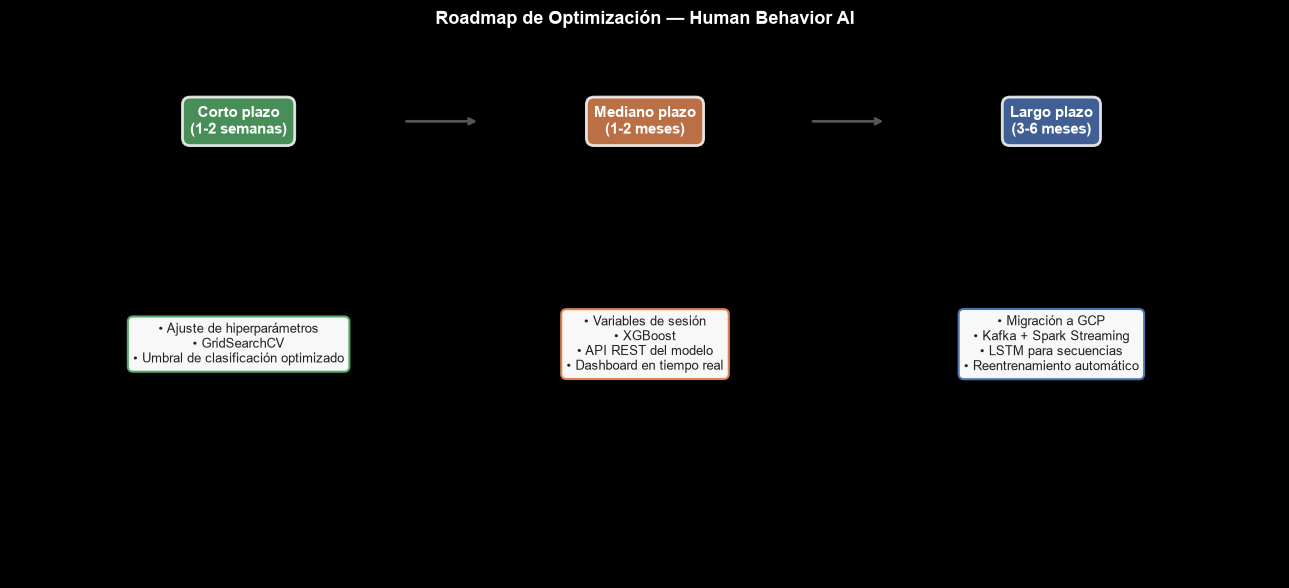

 Gráfico guardado como 'roadmap_optimizacion.png'


In [33]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.axis('off')

fases_roadmap = [
    ("Corto plazo\n(1-2 semanas)",
     "• Ajuste de hiperparámetros\n• GridSearchCV\n• Umbral de clasificación optimizado",
     "#55A868"),
    ("Mediano plazo\n(1-2 meses)",
     "• Variables de sesión\n• XGBoost\n• API REST del modelo\n• Dashboard en tiempo real",
     "#DD8452"),
    ("Largo plazo\n(3-6 meses)",
     "• Migración a GCP\n• Kafka + Spark Streaming\n• LSTM para secuencias\n• Reentrenamiento automático",
     "#4C72B0"),
]

x_pos = [0.18, 0.50, 0.82]

for i, (titulo, contenido, color) in enumerate(fases_roadmap):
    # Caja principal
    fancy = dict(boxstyle="round,pad=0.5", facecolor=color,
                 alpha=0.85, edgecolor='white', linewidth=2)
    ax.text(x_pos[i], 0.82, titulo,
            transform=ax.transAxes,
            fontsize=11, fontweight='bold', color='white',
            ha='center', va='center', bbox=fancy)

    # Contenido
    ax.text(x_pos[i], 0.42, contenido,
            transform=ax.transAxes,
            fontsize=9.5, color='#222222',
            ha='center', va='center',
            bbox=dict(boxstyle="round,pad=0.4",
                      facecolor='#f8f8f8',
                      edgecolor=color,
                      linewidth=1.5))

    # Flechas entre cajas
    if i < 2:
        ax.annotate('', xy=(x_pos[i+1] - 0.13, 0.82),
                    xytext=(x_pos[i] + 0.13, 0.82),
                    xycoords='axes fraction',
                    textcoords='axes fraction',
                    arrowprops=dict(arrowstyle='->',
                                   color='#555555', lw=2))

ax.set_title('Roadmap de Optimización — Human Behavior AI',
             fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('roadmap_optimizacion.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Gráfico guardado como 'roadmap_optimizacion.png'")

---
## 9. Conclusiones de la Fase 6

Esta fase consolidó el análisis de cómo el sistema Human Behavior AI
funcionaría en un entorno real de producción.

**Escalabilidad:**
El sistema fue diseñado con una arquitectura por capas que permite crecer
progresivamente desde el entorno académico actual hasta una infraestructura
distribuida con Apache Spark y Kafka, sin necesidad de rediseñar la solución.

**Nube:**
La migración a Google Cloud Platform permitiría procesar millones de eventos
diarios con alta disponibilidad, utilizando servicios administrados que
eliminan la gestión de infraestructura física.

**Seguridad y gobierno:**
El sistema contempla cifrado, control de acceso por roles, anonimización
de datos y cumplimiento con normativas vigentes, garantizando el manejo
responsable de la información de los usuarios.

**Costos:**
La implementación en GCP tendría un costo estimado de $164 USD mensuales
utilizando Cloud Scheduler como orquestador, lo cual es viable para una
organización pequeña o startup de seguridad digital.

**Optimización:**
La principal línea de mejora identificada es la incorporación de variables
de sesión y secuencia, que permitirían superar el rendimiento del 50%
obtenido en la Fase 4 y llevar el sistema a niveles de detección reales.

